In [367]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.model_selection import train_test_split

In [368]:
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
csv_path = os.path.join(path, "WineQT.csv")
df = pd.read_csv(csv_path)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [369]:
print(f"Dataset com dimensão:", df.shape)

Dataset com dimensão: (1143, 13)


In [370]:
# Verifica quantidade de missing values
df_mv = pd.DataFrame({
    'missing values': df.isna().sum()
})

print(df_mv.to_string())

                      missing values
fixed acidity                      0
volatile acidity                   0
citric acid                        0
residual sugar                     0
chlorides                          0
free sulfur dioxide                0
total sulfur dioxide               0
density                            0
pH                                 0
sulphates                          0
alcohol                            0
quality                            0
Id                                 0


In [371]:
# Verifica duplicatas
print(f"Quantidade de registros duplicados: {df.duplicated().sum()}")

Quantidade de registros duplicados: 0


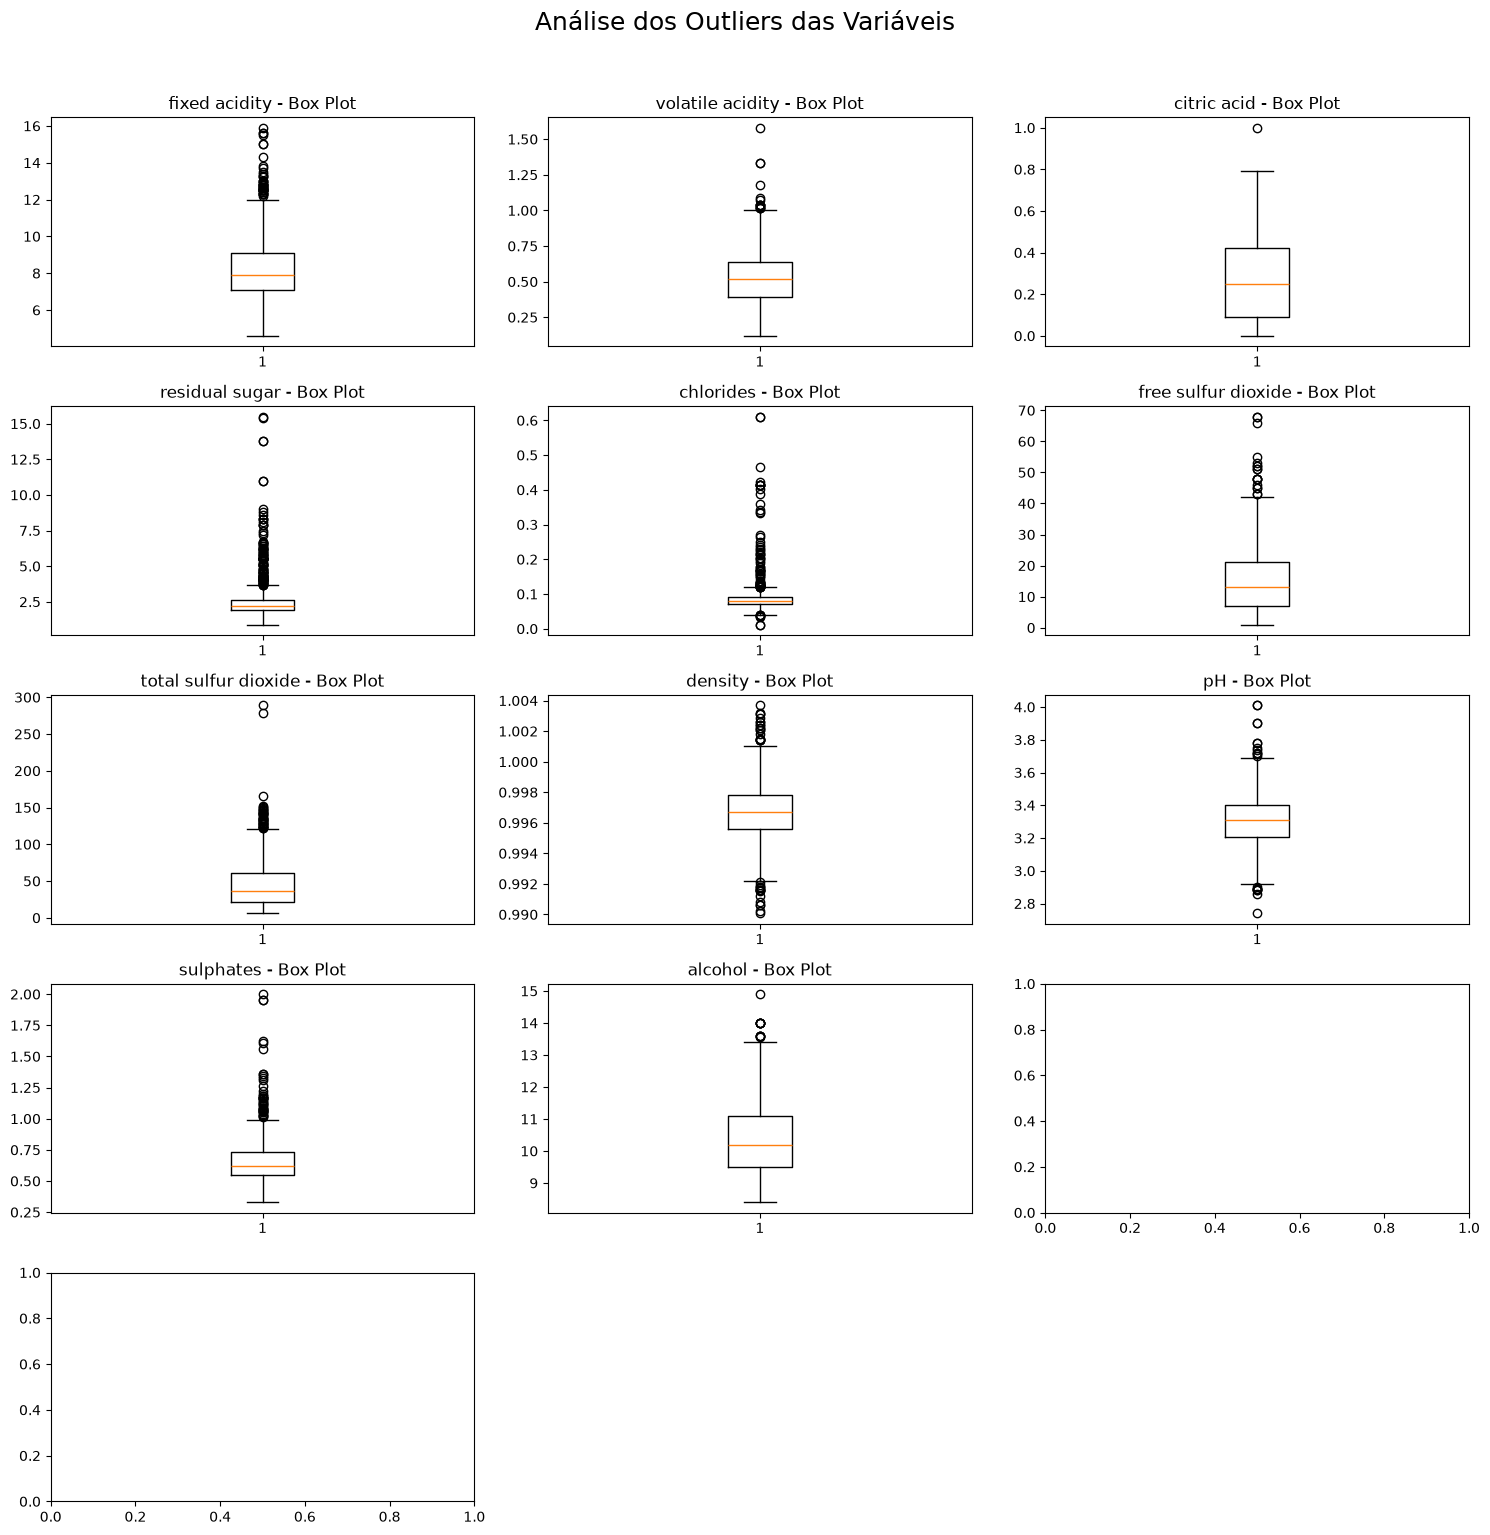

In [372]:
fig, axes = plt.subplots(5, 3, figsize=(15, 15))
fig.suptitle("Análise dos Outliers das Variáveis", fontsize=18, y=1.02)

axes = axes.flatten()

features = [col for col in df.columns if col not in ['Id', 'quality']]
for i, var in enumerate(features):
    axes[i].boxplot(df[var])
    axes[i].set_title(f'{var} - Box Plot')

# Remove subplots vazios
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [373]:
# Distribuição de valores da variável alvo
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

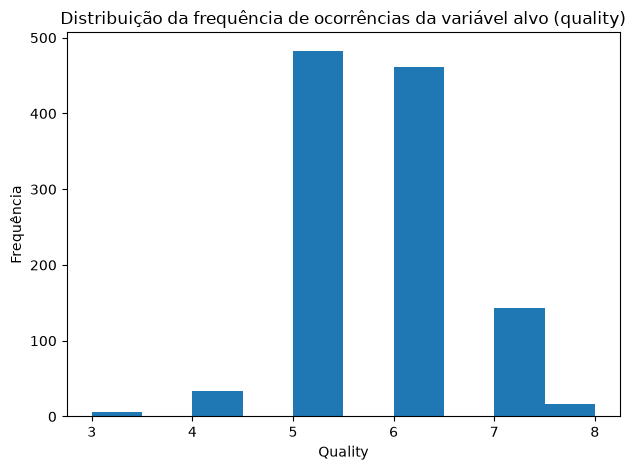

In [374]:
# Histograma da variável alvo para visualização da distribuição
plt.hist(x=df['quality'])

plt.title('Distribuição da frequência de ocorrências da variável alvo (quality)')
plt.xlabel('Quality')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

A partir disso, podemos perceber um desbalanceamento, que será discutida posteriormente e terá um impacto na performance do modelo.

---

In [375]:
# Remove coluna de Id (desnecessária para inferência)
df.drop(columns=['Id'], inplace=True)

Os outliers não serão removidos, mas serão tratados por meio do Robust Scaler, que realiza a centralização dos dados no intervalo interquartil.

$$ \text{Scaled Value} = \frac{x-q_2}{Q_3-Q_1} $$

Isso acontece porque o cálculo usado desconsidera os dados fora do intervalo interquartil para o cálculo da escala, o que permite que o outlier não achate os dados desse intervalo, diminuindo a capacidade de discrimização de algoritmos como o KNN.

In [376]:
# Divisão do conjunto de dados entre treino e teste (validação será cruzada)
X = df.drop(columns=['quality'])
y = df['quality']

X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

---

In [377]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [378]:
knn = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=1))
])

In [379]:
param_grid = {
    'knn__n_neighbors': list(range(1, 200)),
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_treino, Y_treino)

print(f"Melhor valor de K: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Melhor Acurácia na Validação Cruzada: {grid_search.best_score_:.4f}")

Melhor valor de K: 64
Melhor Acurácia na Validação Cruzada: 0.5711


In [380]:
test_acc = grid_search.score(X_teste, Y_teste)
print(f"Acurácia no dataset de Teste: {test_acc:.4f}")

Acurácia no dataset de Teste: 0.6157


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.75      0.72        97
           6       0.55      0.73      0.63        92
           7       0.33      0.03      0.06        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.26      0.25      0.24       229
weighted avg       0.56      0.62      0.57       229



/home/user/Desktop/ml-ds/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/Desktop/ml-ds/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/Desktop/ml-ds/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

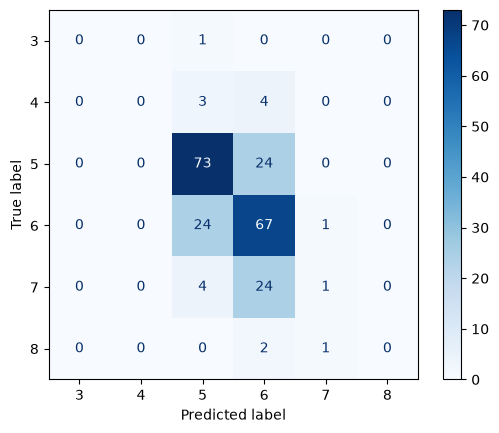

In [381]:
y_pred = grid_search.predict(X_teste)
print(classification_report(Y_teste, y_pred))

ConfusionMatrixDisplay.from_predictions(y_true=Y_teste, y_pred=y_pred, cmap=plt.cm.Blues)

Nesse dataset existe um grande desbalanceamento de classes para a variável alvo, o que atrapalha bastante na predição, visto que vizinhos de notas mais raras ficam sobrepostos pela maioria. Vamos tentar uma abordagem que permite que o KNN funcione melhor.

### Mudando o problema para uma classificação binária

In [382]:
df_bin = df.copy()
df_bin.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [383]:
# Classificando good=1 como nota maior ou igual a 6
df_bin['good'] = df_bin['quality'].apply(lambda x: 1 if x >= 6 else 0)
df_bin.drop(columns=['quality'], inplace=True)

In [384]:
df_bin.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,good
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


Vamos verificar mais uma vez a distribuição dos valores para variável alvo.

In [385]:
# Distribuição de valores da variável alvo
df_bin['good'].value_counts().sort_index()

good
0    522
1    621
Name: count, dtype: int64

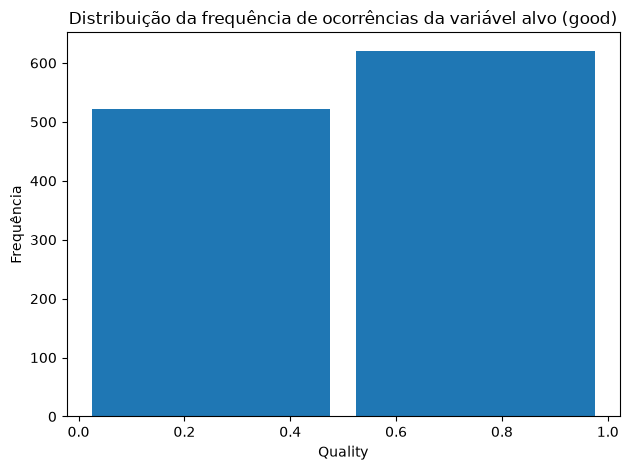

In [386]:
# Histograma da variável alvo para visualização da distribuição
plt.hist(x=df_bin['good'], bins=2, rwidth=0.9)

plt.title('Distribuição da frequência de ocorrências da variável alvo (good)')
plt.xlabel('Quality')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

O tratamento já foi devidamente realizado na parte inicial, podemos partir diretamente para a inferência.

In [387]:
# Divisão do conjunto de dados entre treino e teste (validação será cruzada)
X = df_bin.drop(columns=['good'])
y = df_bin['good']

X_treino, X_teste, Y_treino, Y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [388]:
knn = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=1))
])

In [389]:
param_grid = {
    'knn__n_neighbors': list(range(1, 200)),
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
grid_search.fit(X_treino, Y_treino)

print(f"Melhor valor de K: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Melhor Acurácia na Validação Cruzada: {grid_search.best_score_:.4f}")

Melhor valor de K: 45
Melhor Acurácia na Validação Cruzada: 0.7760


In [390]:
test_acc = grid_search.score(X_teste, Y_test)
print(f"Acurácia no dataset de Teste: {test_acc:.4f}")

Acurácia no dataset de Teste: 0.7860


              precision    recall  f1-score   support

           0       0.76      0.70      0.73       105
           1       0.76      0.81      0.79       124

    accuracy                           0.76       229
   macro avg       0.76      0.75      0.76       229
weighted avg       0.76      0.76      0.76       229



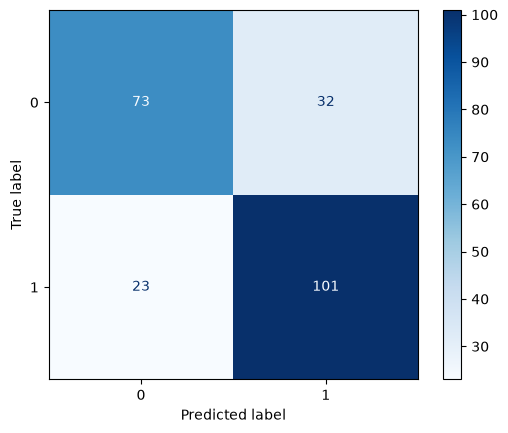

In [391]:
y_pred = grid_search.predict(X_teste)
print(classification_report(Y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_true=Y_test, y_pred=y_pred, cmap=plt.cm.Blues)

Portanto, podemos concluir que o modelo possui uma capacidade de discriminação melhorada de maneira bastante considerável quando temos um problema binário ao invés de multiclasse. Quando dividimos em menos classes, a discrepância entre classes distintas fica mais clara para o modelo e o limiar de decisão fica mais bem definido.